In [13]:
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr
import harmonica as hm

In [14]:
#Primeiro importamos os dados que baixamos no site do ICGEM
malha = hm.load_icgem_gdf(
    fname="../dados/topography_shm_etopo1-2250_62e82f5af0f79fcf0be75535b4c2da34b567809b823ceec384ff5c62179b62b0.gdf"
)
malha

<xarray.Dataset> Size: 94kB
Dimensions:         (latitude: 76, longitude: 151)
Coordinates:
  * latitude        (latitude) float64 608B -60.0 -59.0 -58.0 ... 13.0 14.0 15.0
  * longitude       (longitude) float64 1kB -95.0 -94.0 -93.0 ... 53.0 54.0 55.0
Data variables:
    topography_shm  (latitude, longitude) float64 92kB -4.965e+03 ... -2.373e+03
Attributes: (12/28)
    generating_institute:  gfz-potsdam
    generating_date:       2026/09/18
    product_type:          topography
    body:                  earth
    modelname:             etopo1
    max_used_degree:       2250
    ...                    ...
    maxvalue:              5.1208980E+03 meter
    minvalue:              -7.5776088E+03 meter
    signal_wrms:           2.3985726E+03 meter
    grid_format:           long_lat_value
    attributes:            longitude latitude topography_shm
    attributes_units:      deg. deg. meter

In [15]:
df = (
    malha["topography_shm"]
    .to_dataframe()
    .reset_index()
    .drop_duplicates(subset="topography_shm")
)

latitude = df["latitude"].values
longitude = df["longitude"].values
topografia = df["topography_shm"].values / 1000

print(latitude.shape, longitude.shape, topografia.shape)

(11476,) (11476,) (11476,)


In [16]:
# Definimos valores de densidade para a crosta, manto e água
rhoc = 2.67 # Crosta g/cm3
rhom = 3.30 # Manto g/cm3
rhow = 1.03 # Água g/cm3
# Definimos uma espessura crustal de referência
crust = 30.0 # km 
# Cria um vetor vazio do mesmo tamanho da topografia
espessura = np.zeros_like(topografia)

print(latitude.size)

11476


In [17]:
# Definimos a eq de Airy para o continente
continente = topografia > 0 
a = topografia[continente]
b = rhoc * a / (rhom -rhoc)
espessura[continente] = crust + a + b
# Definimos a eq de Airy para o oceano
oceano = topografia < 0
h = -topografia[oceano] # Batimetria com espessura positiva
d = h * (rhoc - rhow) / (rhom - rhoc)
espessura[oceano] = crust - h - d


Text(0.5, 1.0, 'Espessura Crustal')

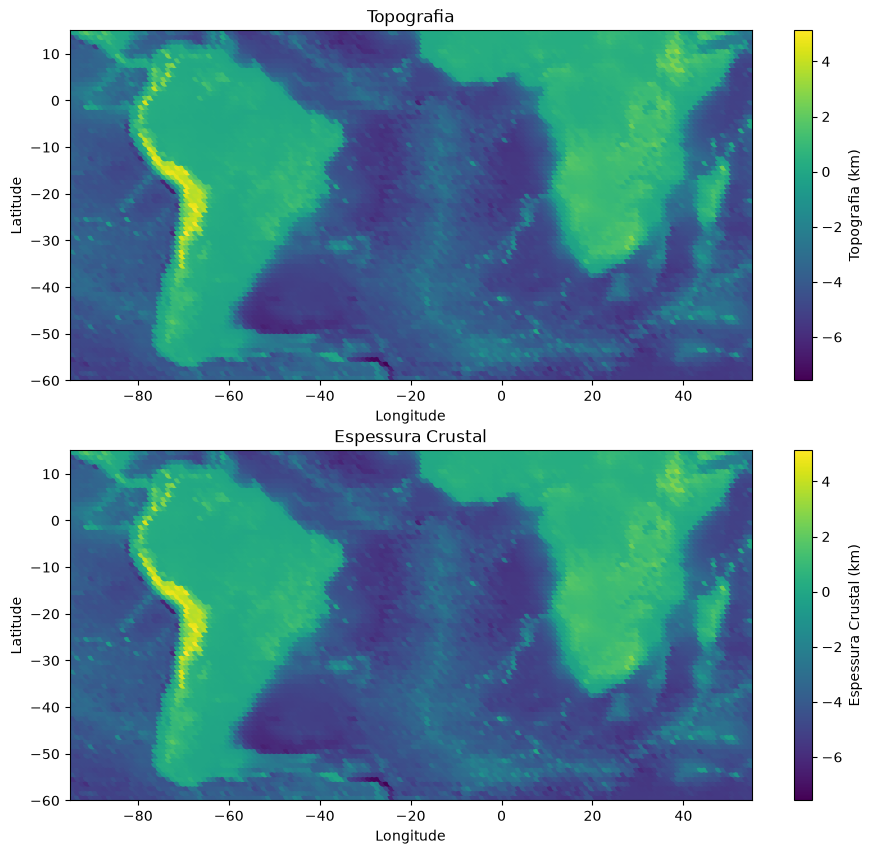

In [18]:
# Vamos plotar esses dados
plt.figure(figsize=(11,10))
# Topografia 
plt.subplot(2, 1 ,1)
plt.scatter(longitude, latitude, c = topografia)
plt.colorbar(label = 'Topografia (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Topografia")
# Espessura crustal 
plt.subplot(2, 1 ,2)
plt.scatter(longitude, latitude, c = topografia)
plt.colorbar(label = 'Espessura Crustal (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Espessura Crustal")

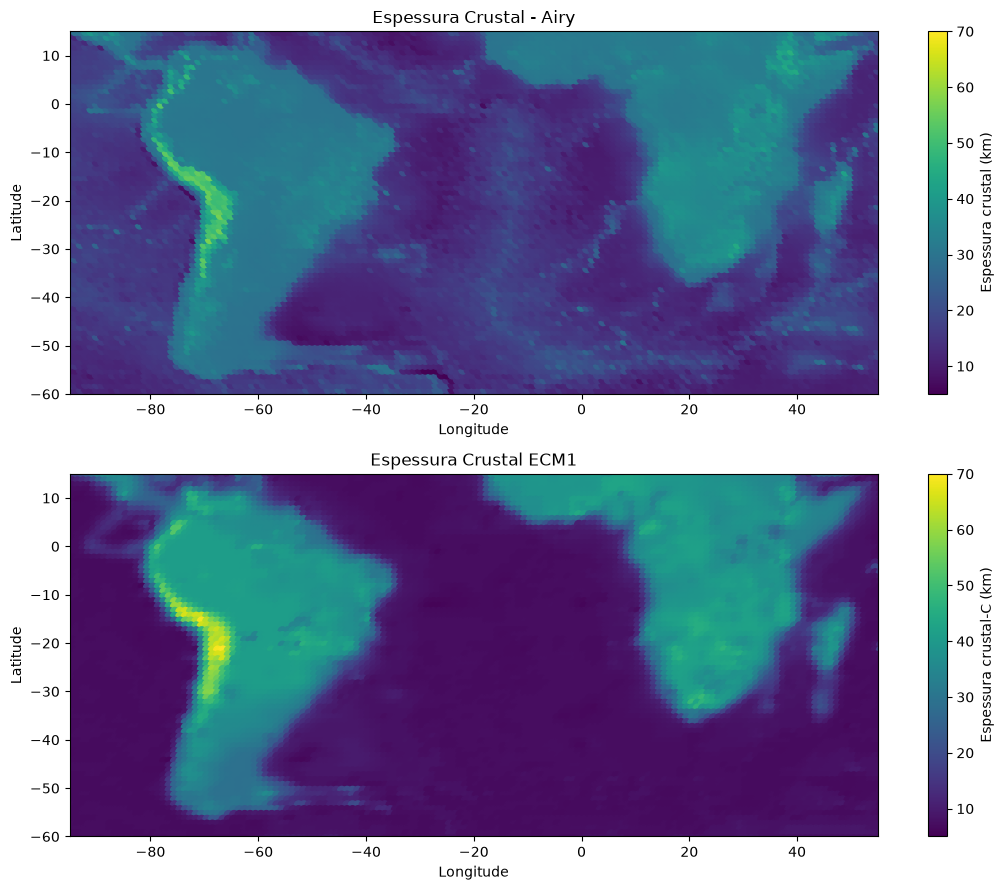

In [19]:
arquivo_crust = '../dados/TotalThickness_ECM1.txt'

plt.figure(figsize=(11,9))

crust_1= np.loadtxt(arquivo_crust, skiprows=1, usecols=(1, 2, 4))

lon_c = crust_1[:, 0]
lat_c = crust_1[:, 1]
esp_c = crust_1[:, 2]

plt.subplot(2, 1, 1)

plt.scatter(longitude, latitude, c=espessura, vmin=5, vmax=70)
plt.colorbar(label='Espessura crustal (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Espessura Crustal - Airy')

plt.subplot(2, 1, 2)

plt.scatter(lon_c, lat_c, c=esp_c, vmin=5, vmax=70)
plt.colorbar(label='Espessura crustal-C (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Espessura Crustal ECM1')

plt.tight_layout()

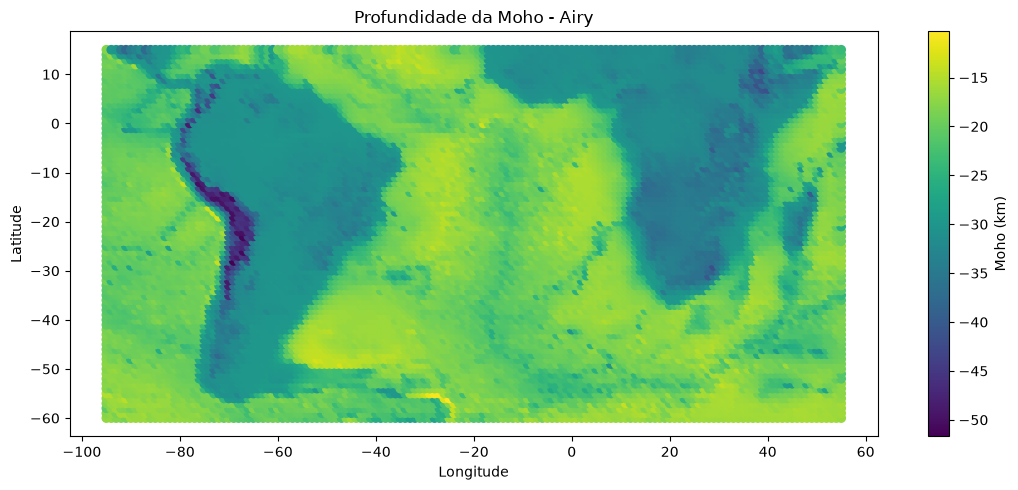

In [20]:
#calculando a moho
moho = np.zeros_like(espessura)
#Para continente
moho[continente] = (espessura[continente] - a)*-1

#Para oceano

moho[oceano] = (espessura[oceano] + h)*-1

plt.figure(figsize=(11,5))

plt.scatter(longitude, latitude, c=moho)
plt.colorbar(label='Moho (km)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Profundidade da Moho - Airy')

           

plt.tight_layout()


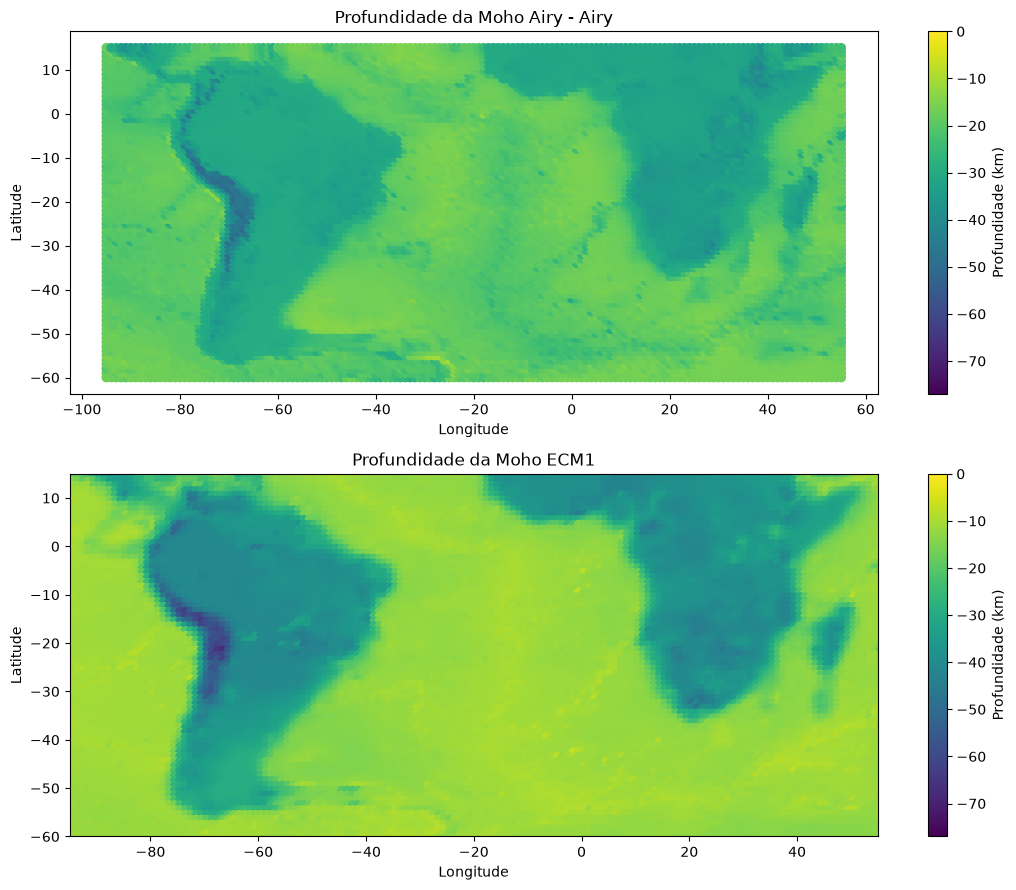

In [21]:
arquivo_crust_moho = '../dados/Depth2Moho_ECM1.txt'

moho_ecm1 = np.loadtxt(arquivo_crust_moho, skiprows=1, usecols=(1, 2, 3))

lon_m = moho_ecm1[:, 0]
lat_m = moho_ecm1[:, 1]
moho_crust_1 = moho_ecm1[:, 2] * -1 

plt.figure(figsize=(11,9))
plt.subplot(2, 1, 1)

plt.scatter(longitude, latitude, c=moho, vmin=0, vmax=-70)
plt.colorbar(label='Profundidade (km)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Profundidade da Moho Airy - Airy')

plt.subplot(2, 1, 2)

plt.scatter(lon_c, lat_c, c=moho_crust_1, vmin=0, vmax=-70)
plt.colorbar(label='Profundidade (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Profundidade da Moho ECM1')

plt.tight_layout()